<a href="https://colab.research.google.com/github/samareddy105-blip/simple-crud-backend/blob/master/solar_radiation_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using ZIP file: /content/srp.zip
CSV files found in zip: ['SolarPrediction.csv']
Using CSV file: /content/srp_extracted/SolarPrediction.csv

Columns in the dataset:
Index(['UNIXTime', 'Data', 'Time', 'Radiation', 'Temperature', 'Pressure',
       'Humidity', 'WindDirection(Degrees)', 'Speed', 'TimeSunRise',
       'TimeSunSet'],
      dtype='object')

Columns after dropping unused ones:
Index(['UNIXTime', 'Radiation', 'Temperature', 'Pressure', 'Humidity',
       'WindDirection(Degrees)', 'Speed'],
      dtype='object')

Feature columns being used:
['UNIXTime', 'Temperature', 'Pressure', 'Humidity', 'WindDirection(Degrees)', 'Speed']

Train shape: (22880, 6), Test shape: (9806, 6)

Training model: LinearRegression

Training model: RandomForest

Training model: GradientBoosting

=== Baseline Model Comparison ===
                   MAE_train  RMSE_train  R2_train    MAE_test   RMSE_test  \
Model                                                                        
LinearRegression  150

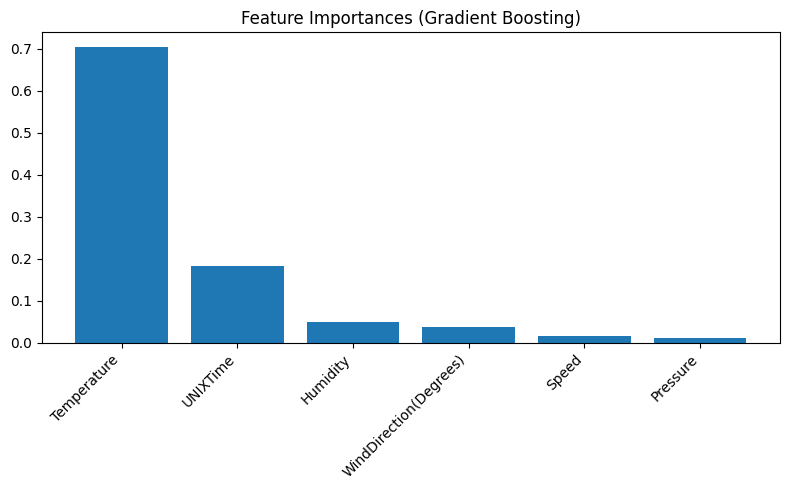


Final model expects features: ['UNIXTime', 'Temperature', 'Pressure', 'Humidity', 'WindDirection(Degrees)', 'Speed']

Example prediction for sample input: 1016.0671130957226


In [3]:
# =====================================================
# 0. SETUP: IMPORTS + UNZIP "srp"
# =====================================================

import os
import zipfile

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

# -------- Unzip the uploaded file named "srp" --------
# Change this if Colab shows a slightly different name
zip_path_candidate = "/content/srp"
final_zip_path = None

if os.path.isfile(zip_path_candidate) and zip_path_candidate.lower().endswith(".zip"):
    final_zip_path = zip_path_candidate
else:
    # Try to guess the actual path if extension got added (like srp.zip)
    import glob
    matches = glob.glob(zip_path_candidate + "*")

    # Prioritize actual .zip files
    zip_files_with_ext = [m for m in matches if os.path.isfile(m) and m.lower().endswith(".zip")]
    if zip_files_with_ext:
        final_zip_path = zip_files_with_ext[0] # Use the first found .zip file
    else:
        # If no .zip file found, look for any file that matches the pattern
        potential_zip_files = [m for m in matches if os.path.isfile(m)]
        if potential_zip_files:
            final_zip_path = potential_zip_files[0] # Use the first found file

if final_zip_path is None:
    raise FileNotFoundError(f"Could not find a file starting with '{zip_path_candidate}' in /content. Check the file name in Colab Files panel.")

print("Using ZIP file:", final_zip_path)

extract_dir = "/content/srp_extracted"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(final_zip_path, "r") as z:
    names = z.namelist()
    csv_files = [n for n in names if n.lower().endswith(".csv")]
    if not csv_files:
        raise ValueError("No .csv file found inside the zip.")
    print("CSV files found in zip:", csv_files)
    z.extractall(extract_dir)

# Take the first CSV file as the dataset
csv_path = os.path.join(extract_dir, csv_files[0])
print("Using CSV file:", csv_path)


# =====================================================
# 1. LOAD & PREPARE DATA
# =====================================================

df_solar = pd.read_csv(csv_path)

print("\nColumns in the dataset:")
print(df_solar.columns)

# Drop unused columns if they exist (as per your project)
cols_to_drop = ['Data', 'Time', 'TimeSunRise', 'TimeSunSet']
df_solar = df_solar.drop(columns=cols_to_drop, errors="ignore")

print("\nColumns after dropping unused ones:")
print(df_solar.columns)

TARGET_COL = "Radiation"
if TARGET_COL not in df_solar.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in CSV. Available columns: {list(df_solar.columns)}")

X = df_solar.drop(columns=[TARGET_COL])
y = df_solar[TARGET_COL]

print("\nFeature columns being used:")
print(list(X.columns))


# =====================================================
# 2. TRAIN–TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")


# =====================================================
# 3. HELPER: EVALUATION FUNCTION
# =====================================================

def evaluate_regression_model(model, X_train, y_train, X_test, y_test):
    """
    Fit the model, predict on train and test,
    and return MAE, RMSE, R2 for train and test.
    """
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    metrics = {
        "MAE_train": mean_absolute_error(y_train, y_train_pred),
        "RMSE_train": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "R2_train": r2_score(y_train, y_train_pred),
        "MAE_test": mean_absolute_error(y_test, y_test_pred),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "R2_test": r2_score(y_test, y_test_pred),
    }
    return metrics


# =====================================================
# 4. BASELINE MODELS + COMPARISON
# =====================================================

models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),  # scaling not necessary but okay
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "GradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingRegressor(random_state=42))
    ])
}

results = []
fitted_models = {}

for name, pipe in models.items():
    print(f"\nTraining model: {name}")
    metrics = evaluate_regression_model(pipe, X_train, y_train, X_test, y_test)
    metrics["Model"] = name
    results.append(metrics)
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).set_index("Model")
print("\n=== Baseline Model Comparison ===")
print(results_df)


# =====================================================
# 5. HYPERPARAMETER TUNING FOR GRADIENT BOOSTING
# =====================================================

print("\nStarting hyperparameter tuning for Gradient Boosting... (this can take a bit)")

gb_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(random_state=42))
])

# Small grid to keep it fast in Colab
param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4],
    "model__subsample": [0.8, 1.0]
}

grid = GridSearchCV(
    gb_pipe,
    param_grid,
    cv=3,  # smaller CV for speed
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\nBest parameters from GridSearchCV:")
print(grid.best_params_)

best_gb = grid.best_estimator_

# Evaluate tuned model
gb_metrics = evaluate_regression_model(best_gb, X_train, y_train, X_test, y_test)
print("\n=== Tuned Gradient Boosting Performance ===")
for k, v in gb_metrics.items():
    print(f"{k}: {v:.4f}")


# =====================================================
# 6. FEATURE IMPORTANCE (TUNED GRADIENT BOOSTING)
# =====================================================

gb_inner = best_gb.named_steps["model"]
importances = gb_inner.feature_importances_

feature_importance = sorted(
    zip(X.columns, importances),
    key=lambda x: -x[1]
)

print("\n=== Feature Importances (Gradient Boosting) ===")
for name, imp in feature_importance:
    print(f"{name}: {imp:.4f}")

plt.figure(figsize=(8, 5))
names = [f[0] for f in feature_importance]
vals = [f[1] for f in feature_importance]
plt.bar(names, vals)
plt.xticks(rotation=45, ha="right")
plt.title("Feature Importances (Gradient Boosting)")
plt.tight_layout()
plt.show()


# =====================================================
# 7. FINAL MODEL + PREDICTION FUNCTION
# =====================================================

final_model = best_gb

# If your dataset has exactly these feature names, we can define the function like this:
EXPECTED_FEATURES = list(X.columns)
print("\nFinal model expects features:", EXPECTED_FEATURES)

def predict_solar_radiation(
    unixtime,
    temperature,
    pressure,
    humidity,
    wind_direction_degrees,
    speed
):
    """
    Predict solar radiation using the tuned final_model.
    Adjust keys here if your column names are different.
    """
    input_dict = {}

    # Map arguments to the actual column names in X.
    # Change keys here if your CSV uses different names.
    input_dict["UNIXTime"] = unixtime
    input_dict["Temperature"] = temperature
    input_dict["Pressure"] = pressure
    input_dict["Humidity"] = humidity
    input_dict["WindDirection(Degrees)"] = wind_direction_degrees
    input_dict["Speed"] = speed

    # Keep only columns that really exist in X and in this mapping
    for col in EXPECTED_FEATURES:
        if col not in input_dict:
            raise ValueError(f"Feature '{col}' is expected by the model but not provided in predict_solar_radiation().")

    input_df = pd.DataFrame([input_dict])

    prediction = final_model.predict(input_df)[0]
    return float(prediction)


# Example usage
try:
    example_pred = predict_solar_radiation(
        unixtime=1472620200,
        temperature=75.0,
        pressure=30.0,
        humidity=40.0,
        wind_direction_degrees=180.0,
        speed=5.0
    )
    print("\nExample prediction for sample input:", example_pred)
except Exception as e:
    print("\nCould not run example prediction. Reason:", e)


# =====================================================
# 8. OPTIONAL: INTERACTIVE INPUT
# =====================================================

def ask_and_predict():
    """
    Ask the user for inputs in a Colab cell
    and print the predicted solar radiation.
    """
    print("\nEnter values to predict solar radiation:\n")
    unixtime = float(input("UNIXTime: "))
    temperature = float(input("Temperature (F): "))
    pressure = float(input("Pressure (inHg): "))
    humidity = float(input("Humidity (%): "))
    wind_direction = float(input("Wind direction (degrees): "))
    speed = float(input("Wind speed (mph): "))

    pred = predict_solar_radiation(
        unixtime, temperature, pressure, humidity, wind_direction, speed
    )

    print("\nPredicted Solar Radiation:", pred)

# To use:
# ask_and_predict()

In [4]:
import joblib

joblib.dump(final_model, "/content/solar_model.pkl")
joblib.dump(EXPECTED_FEATURES, "/content/solar_features.pkl")


['/content/solar_features.pkl']